# 03 — Baseline models

Phase 3: **Logistic Regression** and **Decision Tree** with sklearn **defaults** (`random_state=42` only; LR `max_iter=2000` so it can converge).

- Arrays: `dataset/processed/X_*.npy`, `y_*.npy`, `feature_names.json` (Phase 2).
- **`models/preprocessor.pkl` is not loaded or written.**
- Random Forest / XGBoost: Phase 4. Hyperparameter tuning: Phase 6.

Script: `ml/train.py`.

In [ ]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

ROOT = Path.cwd()
if not (ROOT / "ml" / "train.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.train import run_training

sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)

ROOT: G:\SLIIT Academy\6th Semester\FDM\FDM Project\FDM_Project


## 1. Train baselines

`run_training()` fits both models, writes pickles + `reports/baseline_metrics.csv`, and does **not** touch the preprocessor.

In [ ]:
result = run_training()
comparison = result["comparison"]
display(comparison.round(4))

pre_path = ROOT / "models" / "preprocessor.pkl"
print("preprocessor.pkl exists (unchanged this phase):", pre_path.exists(), "mtime", pre_path.stat().st_mtime)

Phase 3 complete (baselines only; preprocessor.pkl not modified).
              model  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.5665     0.5553  0.4350 0.4878   0.5898
      Decision Tree    0.5184     0.4927  0.4942 0.4934   0.5173
  LR n_iter=11 (max_iter=2000)
  DT depth=56  nodes=74119  leaves=37060
  LR confusion matrix: [[14403, 6613], [10726, 8258]]
  DT confusion matrix: [[11356, 9660], [9603, 9381]]
Top 10 LR coefficients (toward returned):
                       feature  coefficient  abs_coefficient
              bin__used_coupon     0.274879         0.274879
cat__product_category_clothing     0.265694         0.265694
  cat__shipping_method_express     0.205546         0.205546
 cat__payment_method_apple_pay     0.146501         0.146501
      cat__device_type_desktop     0.105756         0.105756
    cat__product_category_toys     0.100337         0.100337
            num__product_price     0.062903         0.062903
  cat__product_category_beauty

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.5665,0.5553,0.4350,0.4878,0.5898
1,Decision Tree,0.5184,0.4927,0.4942,0.4934,0.5173


preprocessor.pkl exists (unchanged this phase): True mtime 1789375053.5851145


## 2. Test metrics and confusion matrices

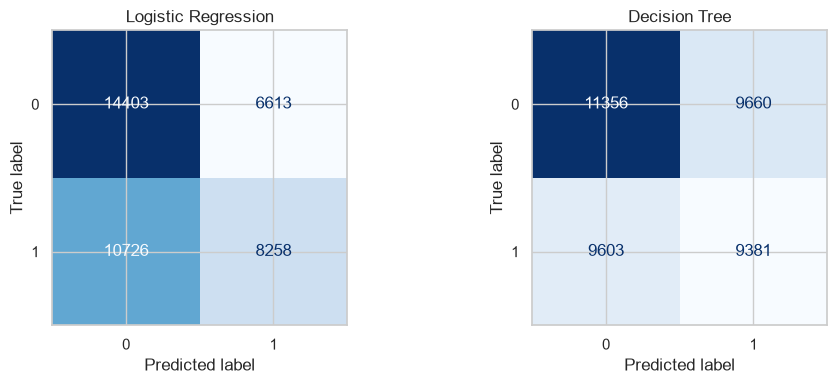

LR {'accuracy': 0.566525, 'precision': 0.5553089906529487, 'recall': 0.43499789296249475, 'f1': 0.4878452222714518, 'roc_auc': 0.5898356334290524}
DT {'accuracy': 0.518425, 'precision': 0.492673704112179, 'recall': 0.4941529709228824, 'f1': 0.49341222879684415, 'roc_auc': 0.5172515901435881}
DT depth / nodes / leaves: 56 74119 37060


In [ ]:
X_test = np.load(ROOT / "dataset" / "processed" / "X_test.npy")
y_test = np.load(ROOT / "dataset" / "processed" / "y_test.npy")
lr = joblib.load(ROOT / "models" / "baseline_logistic_regression.pkl")
dt = joblib.load(ROOT / "models" / "baseline_decision_tree.pkl")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, title in [
    (axes[0], lr, "Logistic Regression"),
    (axes[1], dt, "Decision Tree"),
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG / "07_baseline_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

print("LR", {k: result["lr_metrics"][k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]})
print("DT", {k: result["dt_metrics"][k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]})
print("DT depth / nodes / leaves:", result["dt_metrics"]["tree_depth"], result["dt_metrics"]["node_count"], result["dt_metrics"]["n_leaves"])

### LR vs Decision Tree vs Phase 1 EDA

Phase 1 found **weak numeric linear correlations** (|r| < 0.04) and **clearer category gaps** (~11 pp for `product_category`). That often makes people expect a **tree** to beat a **linear** model, because trees can split on clothing vs electronics without assuming additivity.

**That is not what the default baselines show.** Logistic Regression is better on the hold-out set (accuracy ~0.57, ROC-AUC ~0.59) than the unpruned Decision Tree (accuracy ~0.52, ROC-AUC ~0.52 — close to chance).

Why the tree loses: sklearn’s default `DecisionTreeClassifier` grows until leaves are pure (`max_depth=None`). Here that yields **depth ~56** and **tens of thousands of nodes**, so it memorizes train noise. Weak numeric signals get chopped into spurious splits (see importances below). **Do not read this as “trees cannot work on this problem”** — Phase 4 (RF/XGBoost) and Phase 6 (depth / min_samples tuning) are the fair tree comparison.

LR *does* pick up the EDA category story in its coefficients (next section).

## 3. Logistic Regression coefficients

Positive coefficient → higher log-odds of `returned = 1`. Features are the Phase 2 `ColumnTransformer` names.

Top 10 positive (push toward returned):


,feature,coefficient,abs_coefficient
0,bin__used_coupon,0.2749,0.2749
1,cat__product_category_clothing,0.2657,0.2657
2,cat__shipping_method_express,0.2055,0.2055
3,cat__payment_method_apple_pay,0.1465,0.1465
4,cat__device_type_desktop,0.1058,0.1058
5,cat__product_category_toys,0.1003,0.1003
6,num__product_price,0.0629,0.0629
7,cat__product_category_beauty,0.0460,0.0460
8,num__past_return_rate,0.0287,0.0287
9,num__discount_percent,0.0248,0.0248


Top 10 negative (push toward not returned):


,feature,coefficient,abs_coefficient
25,cat__product_category_electronics,-0.2662,0.2662
24,cat__device_type_mobile,-0.1750,0.1750
23,cat__shipping_method_same_day,-0.1743,0.1743
22,cat__product_category_home,-0.1403,0.1403
21,cat__payment_method_debit_card,-0.1343,0.1343
20,cat__shipping_method_standard,-0.1334,0.1334
19,cat__product_category_sports,-0.1078,0.1078
18,cat__payment_method_paypal,-0.0856,0.0856
17,num__delivery_delay_days,-0.0644,0.0644
16,num__past_purchase_count,-0.0518,0.0518


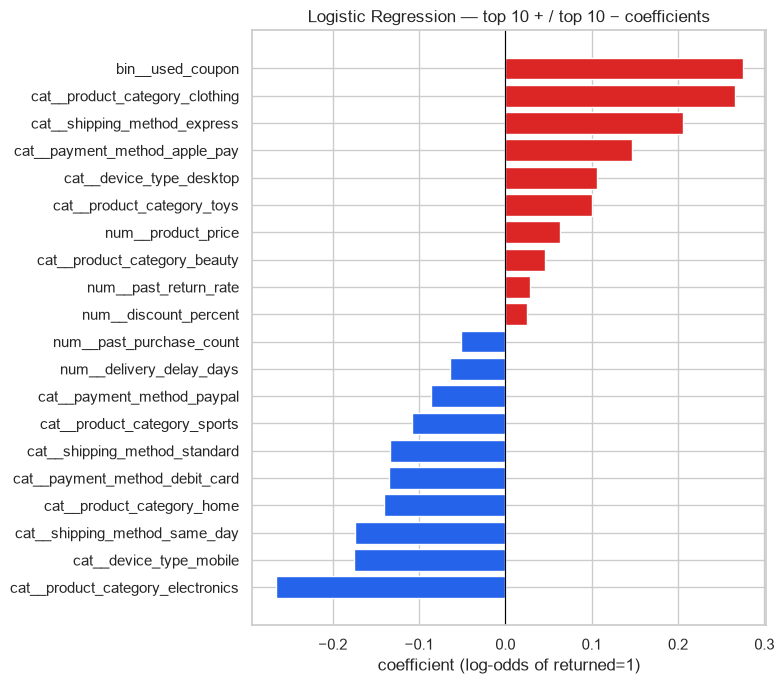

In [ ]:
coef = result["lr_coefficients"]
top_pos = coef.head(10)
top_neg = coef.nsmallest(10, "coefficient")

print("Top 10 positive (push toward returned):")
display(top_pos.round(4))
print("Top 10 negative (push toward not returned):")
display(top_neg.round(4))

plot_df = pd.concat([top_neg, top_pos]).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(8, 7))
colors = np.where(plot_df["coefficient"] >= 0, "#dc2626", "#2563eb")
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("coefficient (log-odds of returned=1)")
ax.set_title("Logistic Regression — top 10 + / top 10 − coefficients")
fig.tight_layout()
fig.savefig(FIG / "08_baseline_lr_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()

These signs match Phase 1 return rates: clothing / express / apple_pay / desktop / coupon **up**; electronics / mobile / same_day / debit_card **down**. `num__product_price` is a small positive (EDA r ≈ +0.03); `num__delivery_delay_days` is negative (earlier delivery associated with slightly more returns in EDA).

## 4. Decision Tree importances (default, unpruned)

depth 56 nodes 74119 leaves 37060
Top 10 feature_importances_:


,feature,importance
0,num__delivery_delay_days,0.1214
1,num__discount_percent,0.1197
2,num__session_length_minutes,0.1182
3,num__past_return_rate,0.1161
4,num__product_rating,0.1116
5,num__product_price,0.1055
6,num__customer_age,0.0955
7,num__num_product_views,0.0799
8,num__past_purchase_count,0.0433
9,cat__payment_method_debit_card,0.0070


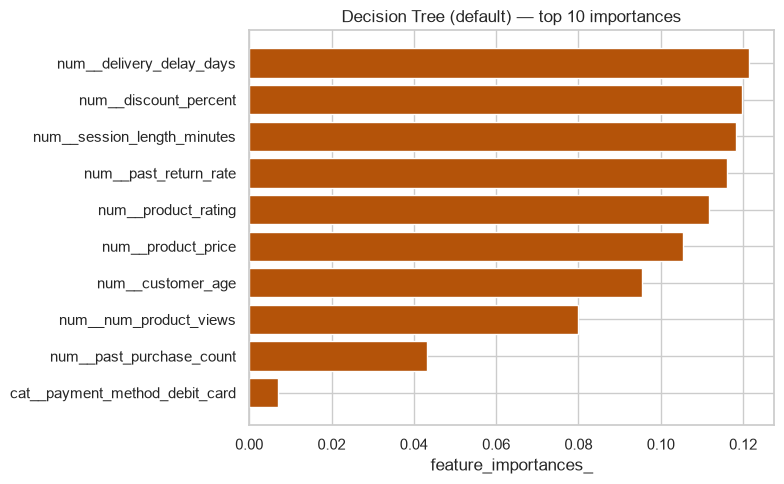

In [ ]:
imp = result["dt_importances"]
print(
    "depth", result["dt_metrics"]["tree_depth"],
    "nodes", result["dt_metrics"]["node_count"],
    "leaves", result["dt_metrics"]["n_leaves"],
)
print("Top 10 feature_importances_:")
display(imp.head(10).round(4))

top = imp.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["importance"], color="#b45309")
ax.set_xlabel("feature_importances_")
ax.set_title("Decision Tree (default) — top 10 importances")
fig.tight_layout()
fig.savefig(FIG / "09_baseline_dt_importances.png", bbox_inches="tight", dpi=150)
plt.show()

Default-tree importances are dominated by **continuous** columns (`delivery_delay_days`, discount, session length, …). That is consistent with an unpruned tree using high-cardinality numerics to carve tiny leaves, **not** with the EDA finding that categories separate returns more. Another reason not to prefer this baseline tree until it is constrained (Phase 6).

## Outputs

| Path | Role |
|------|------|
| `models/baseline_logistic_regression.pkl` | Fitted LR |
| `models/baseline_decision_tree.pkl` | Fitted DT |
| `reports/baseline_metrics.csv` | Comparison table |
| `reports/baseline_lr_coefficients.csv` | All LR coefficients |
| `reports/baseline_dt_importances.csv` | All DT importances |